In [20]:
import pyvista as pv
import numpy as np

stl  = pv.read("constant/triSurface/monobob.stl")
mesh = pv.read("VTK/01_mono_0/boundary/monobob.vtp")

In [21]:
result = mesh.compute_implicit_distance(stl)
d = np.abs(result["implicit_distance"])

print(f"Mean error : {d.mean()*1000:.3f} mm")
print(f"RMS error  : {np.sqrt(np.mean(d**2))*1000:.3f} mm")
print(f"Max error  : {d.max()*1000:.3f} mm")

Mean error : 0.019 mm
RMS error  : 0.252 mm
Max error  : 32.870 mm


In [22]:
result.save("distance_map.vtk")

/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


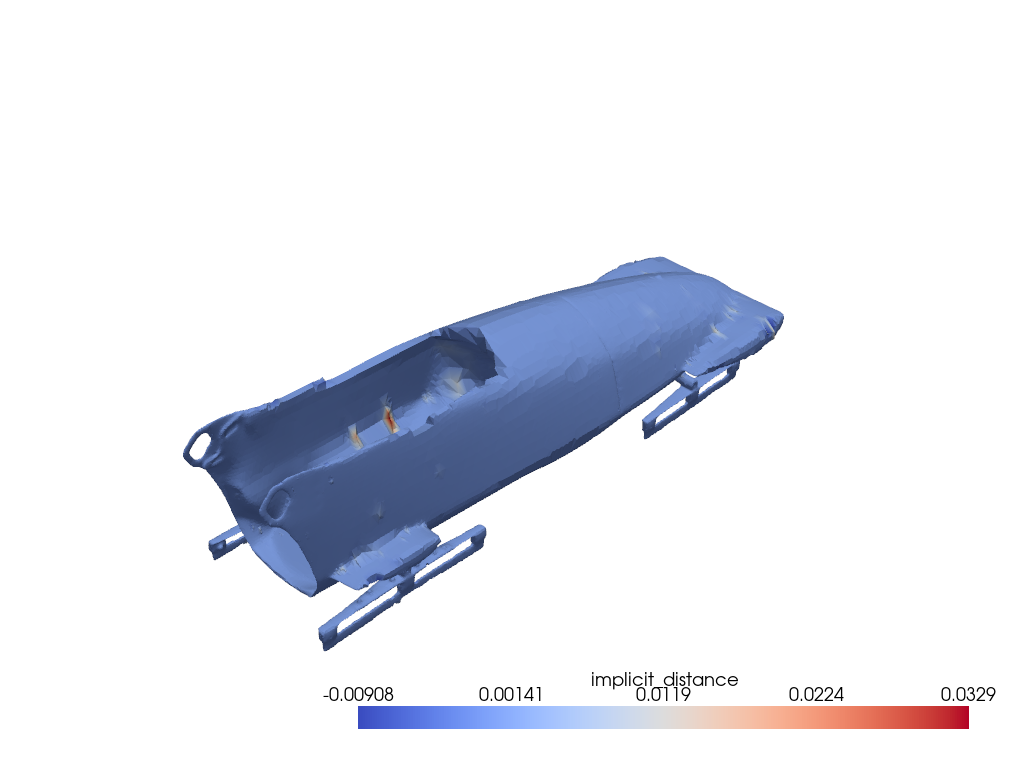

In [23]:
p = pv.Plotter()
p.add_mesh(result, scalars="implicit_distance", cmap="coolwarm")
p.show()

/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (/users/eleves-a/2023/thanh.diep/venvs/cfd/lib64/python3.9/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


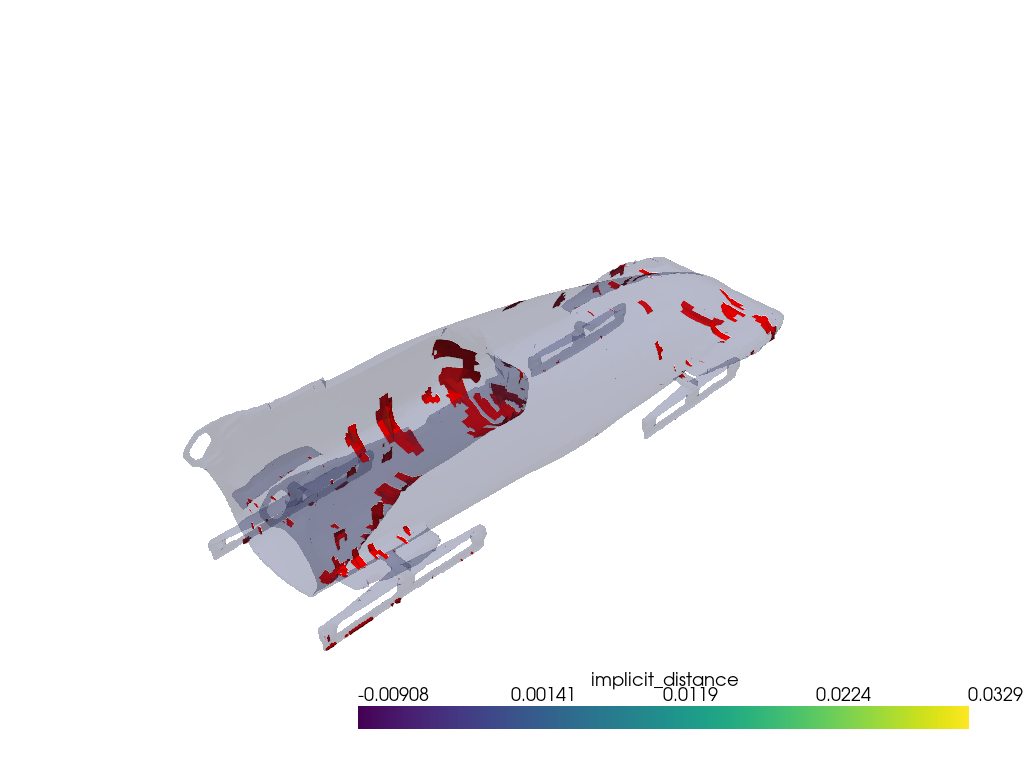

In [24]:
threshold = 0.002
bad = result.threshold(value=threshold, scalars="implicit_distance")
p = pv.Plotter()

p.add_mesh(result, scalars="implicit_distance", opacity=0.2)
p.add_mesh(bad, color="red")
p.show()

In [25]:
pts = bad.points

xmin, ymin, zmin = pts.min(axis=0)
xmax, ymax, zmax = pts.max(axis=0)

print(xmin, ymin, zmin)
print(xmax, ymax, zmax)

print(bad.n_points)

-1.3041369 -0.42914435 0.0
1.2564427 0.42983577 0.6550782
2579


In [17]:
# localize the 26 mm deviation

imax = np.argmax(d)
pmax = mesh.points[imax]

print(d[imax])
print(pmax)

0.033911353623013986
[ 0.42951256 -0.18233393  0.3567545 ]
